Rows after cleaning: 4022
Features used: ['ma_gap_20', 'ma_gap_10', 'vol_10', 'ret_2', 'ret_5', 'ret_1', 'ret_4', 'vol_20', 'ret_3']

=== Accuracy ===
Scratch: 0.4688279301745636
Library: 0.5012468827930174

=== Train Accuracy ===
Scratch: 0.49563318777292575
Library: 0.5801621958827199

=== Log Loss ===
Scratch: 1.1389464948496328
Library: 1.0320128562799775

=== Precision / Recall / F1 (Macro) ===
Scratch: 0.34259259259259256 0.3355795117675207 0.26894110206460903
Library: 0.3391425778522552 0.34724377296855863 0.2591187615692669

=== Confusion Matrix ===
Scratch:
 [[ 11 139   9]
 [ 30 356   9]
 [ 14 225   9]]
Library:
 [[  0 153   6]
 [  0 386   9]
 [  1 231  16]]

=== ROC AUC ===
Scratch: 0.5183086890805577
Library: 0.5372102181221563


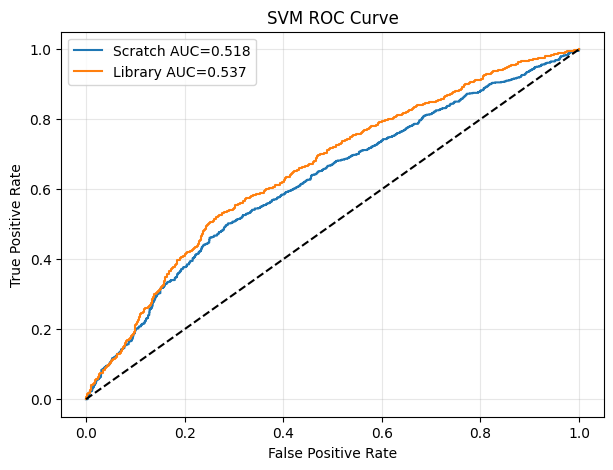

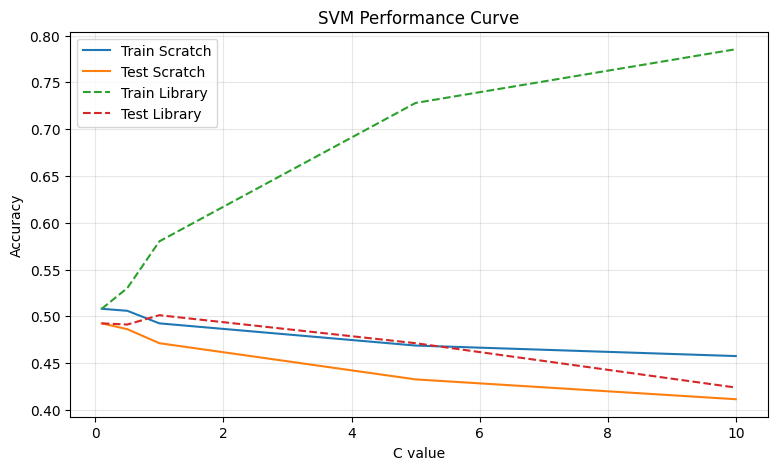

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

WINDOW_SIZE = 14
DATA_PATH = '../CLASSIFY-SnP_daily_update_AMZN_features_with_target.csv'
FEATURE_PATH = '../CLASSIFY-AMZN_methods_all_in_one.csv'
TARGET_COL = 'Target_Return_7d'

UP_THRESHOLD = 0.02
DOWN_THRESHOLD = -0.02

# --------------------------
# 1) Load data
# --------------------------
df = pd.read_csv(DATA_PATH)
feature_df = pd.read_csv(FEATURE_PATH)

requested_features = [
    'ma_gap_20', 'ma_gap_10', 'vol_10',
    'ret_2', 'ret_5',
    'ret_1',
    'ret_4',
    'vol_20',
    'ret_3'
]

allowed_features = feature_df['feature'].tolist() if 'feature' in feature_df.columns else []
feature_cols = [c for c in requested_features if c in allowed_features and c in df.columns]

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

model_df = df[feature_cols + [TARGET_COL]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("Rows after cleaning:", len(model_df))
print("Features used:", feature_cols)

# --------------------------
# 2) Sliding Window
# --------------------------
def make_windows(x_values, y_values, window_size=14):
    Xw, yw = [], []
    for i in range(window_size, len(x_values)):
        Xw.append(x_values[i-window_size:i].reshape(-1))
        yw.append(y_values[i])
    return np.array(Xw), np.array(yw)

def map_target_3class(y_values, up_thr=0.03, down_thr=-0.03):
    y_cls = np.full_like(y_values, 1, dtype=np.int64)
    y_cls[y_values > up_thr] = 2
    y_cls[y_values < down_thr] = 0
    return y_cls

X_raw = model_df[feature_cols].values
y_raw_cont = model_df[TARGET_COL].values
y_raw = map_target_3class(y_raw_cont)

X_win, y_win = make_windows(X_raw, y_raw, WINDOW_SIZE)

split_idx = int(len(X_win) * 0.8)
X_train_raw, X_test_raw = X_win[:split_idx], X_win[split_idx:]
y_train, y_test = y_win[:split_idx], y_win[split_idx:]

# Standardize
x_mean = X_train_raw.mean(axis=0)
x_std = X_train_raw.std(axis=0)
x_std = np.where(x_std == 0, 1, x_std)

X_train = (X_train_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

# ------------------------------------------
# 3) SVM from scratch (Linear, OvR)
# ------------------------------------------
class LinearSVM_Scratch:
    def __init__(self, lr=0.0005, C=1.0, epochs=500):
        self.lr = lr
        self.C = C
        self.epochs = epochs

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)
        
        self.W = np.zeros((n_classes, n_features))
        self.b = np.zeros(n_classes)

        for idx, c in enumerate(self.classes_):
            y_binary = np.where(y == c, 1, -1)
            w = np.zeros(n_features)
            b = 0

            for _ in range(self.epochs):
                for i, x_i in enumerate(X):
                    condition = y_binary[i] * (np.dot(x_i, w) + b) >= 1
                    if condition:
                        w -= self.lr * (2 * w)
                    else:
                        w -= self.lr * (2 * w - self.C * y_binary[i] * x_i)
                        b -= self.lr * (-self.C * y_binary[i])

            self.W[idx] = w
            self.b[idx] = b

    def decision_function(self, X):
        return X @ self.W.T + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.argmax(scores, axis=1)

    def predict_proba(self, X):
        scores = self.decision_function(X)
        exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
        return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

# Train Scratch
scratch_model = LinearSVM_Scratch()
scratch_model.fit(X_train, y_train)
y_pred_scratch = scratch_model.predict(X_test)
y_prob_scratch = scratch_model.predict_proba(X_test)

# ------------------------------------------
# 4) Library SVM (RBF)
# ------------------------------------------
lib_model = SVC(C=1.0, kernel='rbf', probability=True)
lib_model.fit(X_train, y_train)
y_pred_lib = lib_model.predict(X_test)
y_prob_lib = lib_model.predict_proba(X_test)

# ------------------------
# 5) Metrics
# ------------------------
classes = np.array([0,1,2])

print("\n=== Accuracy ===")
print("Scratch:", accuracy_score(y_test, y_pred_scratch))
print("Library:", accuracy_score(y_test, y_pred_lib))

print("\n=== Train Accuracy ===")
print("Scratch:", np.mean(scratch_model.predict(X_train)==y_train))
print("Library:", lib_model.score(X_train, y_train))

print("\n=== Log Loss ===")
print("Scratch:", log_loss(y_test, y_prob_scratch, labels=classes))
print("Library:", log_loss(y_test, y_prob_lib, labels=classes))

print("\n=== Precision / Recall / F1 (Macro) ===")
print("Scratch:",
      precision_score(y_test, y_pred_scratch, average='macro', zero_division=0),
      recall_score(y_test, y_pred_scratch, average='macro', zero_division=0),
      f1_score(y_test, y_pred_scratch, average='macro', zero_division=0))

print("Library:",
      precision_score(y_test, y_pred_lib, average='macro', zero_division=0),
      recall_score(y_test, y_pred_lib, average='macro', zero_division=0),
      f1_score(y_test, y_pred_lib, average='macro', zero_division=0))

print("\n=== Confusion Matrix ===")
print("Scratch:\n", confusion_matrix(y_test, y_pred_scratch, labels=classes))
print("Library:\n", confusion_matrix(y_test, y_pred_lib, labels=classes))

# ------------------------
# 6) ROC Curve
# ------------------------
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_s = roc_auc_score(y_test_bin, y_prob_scratch, average='macro', multi_class='ovr')
roc_auc_l = roc_auc_score(y_test_bin, y_prob_lib, average='macro', multi_class='ovr')

fpr_s, tpr_s, _ = roc_curve(y_test_bin.ravel(), y_prob_scratch.ravel())
fpr_l, tpr_l, _ = roc_curve(y_test_bin.ravel(), y_prob_lib.ravel())

print("\n=== ROC AUC ===")
print("Scratch:", roc_auc_s)
print("Library:", roc_auc_l)

plt.figure(figsize=(7,5))
plt.plot(fpr_s, tpr_s, label=f"Scratch AUC={roc_auc_s:.3f}")
plt.plot(fpr_l, tpr_l, label=f"Library AUC={roc_auc_l:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------
# 7) Performance Curve (C)
# ------------------------
C_range = [0.1, 0.5, 1, 5, 10]

train_acc_s = []
test_acc_s = []
train_acc_l = []
test_acc_l = []

for c in C_range:

    model_s = LinearSVM_Scratch(C=c, epochs=300)
    model_s.fit(X_train, y_train)
    train_acc_s.append(np.mean(model_s.predict(X_train)==y_train))
    test_acc_s.append(np.mean(model_s.predict(X_test)==y_test))

    model_l = SVC(C=c, kernel='rbf', probability=True)
    model_l.fit(X_train, y_train)
    train_acc_l.append(model_l.score(X_train, y_train))
    test_acc_l.append(model_l.score(X_test, y_test))

plt.figure(figsize=(9,5))
plt.plot(C_range, train_acc_s, label="Train Scratch")
plt.plot(C_range, test_acc_s, label="Test Scratch")
plt.plot(C_range, train_acc_l, linestyle="--", label="Train Library")
plt.plot(C_range, test_acc_l, linestyle="--", label="Test Library")

plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.title("SVM Performance Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()